### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 6</center>
---

### Overview

The first objective of this exercise is to study local image enhancement using histogram statistics.

The second objective is to study spatial smoothing filters using filter masks. Application examples are reducing sharp intensity transitions, noise reduction, and reducing image details. For spatial filtering, the corresponding mask is moved from pixel to pixel and the filter response is computed at each position $(x,y)$.

The following figure illustrates the idea:

<br />
<center><img src="images/spatial-filtering.png"  width="600px" /></center>

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

### <span style="color: RoyalBlue; font-weight: bold;">Task 6.1</span> Local Enhancement Using Histogram Statistics

In the last exercise, histogram equalization has been applied to a local neighborhood of each pixel to enhance details in small image areas. Nonetheless, the results are not convincing, as edges are highlighted and noise is amplified. For such problems it can be better to use statistics which can be computed directly or based on the histogram.

For the given test image, the task at hand is to enhance details with low contrast in dark image regions, while leaving light regions unchanged. As the mean is a measure of average intensity, the mean $m_{S_{xy}}$ of an image region $S_{xy}$ can be compared with the global mean $m_G$ to identify dark regions. As the variance is a measure of image contrast, the variance $\sigma_{S_{xy}}$ of an image region can be compared with the global variance $\sigma_G$ to identify regions with low contrast. With appropriate constants $k_0, k_1, k_2, k_3, C$, the task can be formalized as follows:

$$
g(x,y) =
\begin{cases}
C f(x,y) &\ \mathrm{if}\ k_0 m_G \leq m_{S_{xy}} \leq k_1 m_G\ \mathrm{AND}\ k_2 \sigma_G \leq \sigma_{S_{xy}} \leq k_3 \sigma_G\\
f(x,y)   &\ \text{otherwise}
\end{cases}
$$

Implement / solve the following tasks:

1. Write a function to apply local enhancement using the equation from above and $n\times n$ windows ($n$ should be odd).
2. Read an image (squares2.png from the folder *images*) as a grayscale image and plot it.
3. Apply the function to the image using appropriate constants and $n = 3$, then plot and analyze the results.
4. What happens when using a checkerboard? Test it (use checkerboard-small.png from the folder *images*).

*Note*: When implementing neighborhood operations it is necessary to consider what happens when approaching the boundary of the image. In this example, the border can just be left out.

In [2]:
# apply local enhancement image using nxn windows (odd n required)
def enhance_local(img, n, k0, k1, k2, k3, c):
    rows, cols = img.shape # image size
    
    # compute global mean and variance
    m_g = np.mean(img)
    print("global mean = " + str(m_g))
    
    std_g = np.std(img)
    print("global std = " + str(std_g))
    
    # create copy of image
    res = img.copy()
    
    # compute offset
    h = int(n / 2)
    
    # move from pixel to pixel (border is just left out)
    for iy in range(h, rows-h):
        for jx in range(h, cols-h):
            # get local neighborhood
            nbh = img[iy-h:iy+h+1, jx-h:jx+h+1]
            
            # compute local mean and variance
            m_l = np.mean(nbh)
            std_l = np.std(nbh)
            
            # process pixels
            if (k0*m_g <= m_l and m_l <= k1*m_g and k2*std_g <= std_l and std_l <= k3*std_g):
                res[iy, jx] = c * img[iy, jx]
            
            # print some status information
        print("row = " + str(iy), end='\r') # current row
            
    # return final result
    return res

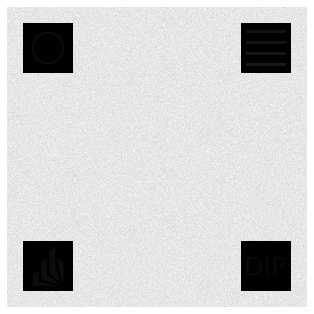

In [3]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/squares2.png', 0)
plot_img_orig(img)

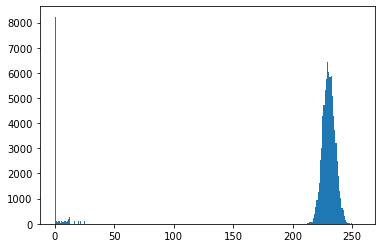

In [4]:
# check histogram
plt.hist(img.flatten(), 255, [0, 256])
plt.show()

In [5]:
hist, bins = np.histogram(img, bins=np.arange(257)) # bins are the bin edges (e.g. 2 values require 3 edges)
print(hist) # check numerical values

[8170   63   93   78   93   48  108   55   54   97   74  109  194  284
    0    0    0  120    0    0  120    0  120    0    0  120    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

global mean = 204.7017888888889
global std = 71.80025311871114


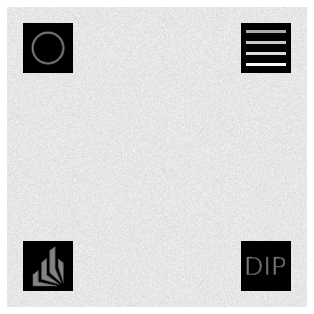

In [6]:
# enhance image and plot the result
res = enhance_local(img, 3, 0, 0.2, 0, 0.2, 10.0)
plot_img_orig(res)

global mean = 127.704
global std = 127.49983679989555


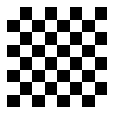

In [7]:
# test for checkerboard
img_cb = cv2.imread('images/checkerboard-small.png', 0)
res = enhance_local(img_cb, 3, 0, 0.2, 0, 0.2, 10.0)
plot_img_orig(res)

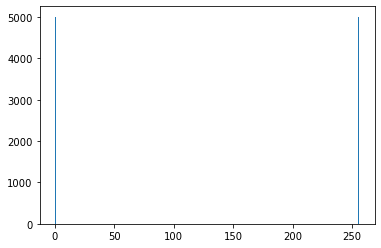

In [8]:
plt.hist(res.flatten(), 255, [0, 256])
plt.show()

Using image statistics yields to much better results, the hidden symbols become clearly visible. Even different intensity levels can be detected (see top right). The noise in the background is not amplified.

The checkerboard does not change because there are no low contrast regions.

### <span style="color: RoyalBlue; font-weight: bold;">Task 6.2</span> Boundary Padding

When using filter masks it is necessary to consider what happens when the center of the mask approaches the image boundary. Different solutions are possible, for example:

* Leave out the boundary (start with an approporiate distance to the boundary, typically $(n-1)/2$ for a $n \times n$ mask).
* Use a partial filter mask at the boundary.
* Zero- or constant padding (`iiiiii|abcdefgh|iiiiiii`, where `i` is zero or constant).
* Replication (`aaaaaa|abcdefgh|hhhhhhh`).
* Reflection (`fedcba|abcdefgh|hgfedc` or `gfedcb|abcdefgh|gfedcba`).

For many OpenCV functions, the method to be used can be specified by passing the <a href="https://docs.opencv.org/4.2.0/d2/de8/group__core__array.html#ga209f2f4869e304c82d07739337eae7c5">`BorderType` ↗</a> as a parameter. The functions usually copy the given image, pad the boundary, then perform the filtering, and finally remove the extra boundary. For padding images directly, the OpenCV function <a href="https://docs.opencv.org/4.2.0/d2/de8/group__core__array.html#ga2ac1049c2c3dd25c2b41bffe17658a36">`copyMakeBorder()` ↗</a> can be used.

Implement the following tasks:
1. Read an image (fruits-small.png from the folder *images*) as a grayscale image and plot it.
2. For this image, test the following padding methods and plot the results: zero padding, replication, reflection.
3. Remove the extra boundary from the zero padded image and plot the result.

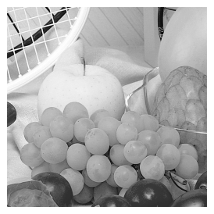

In [9]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/fruits-small.png', 0)
plot_img_orig(img)

In [10]:
# padding size
b = 20

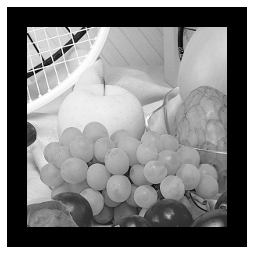

In [11]:
# zero padding
img_zp = cv2.copyMakeBorder(img, b, b, b, b, cv2.BORDER_CONSTANT)
plot_img_orig(img_zp)

In [14]:
print("image size before and after padding: ", img.size, img_zp.size)

image size before and after padding:  40000 57600


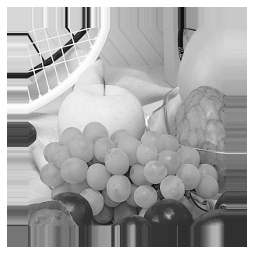

In [12]:
# replication
img_rp = cv2.copyMakeBorder(img, b, b, b, b, cv2.BORDER_REPLICATE)
plot_img_orig(img_rp)

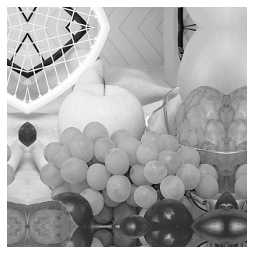

In [13]:
# reflection
img_rf = cv2.copyMakeBorder(img, b, b, b, b, cv2.BORDER_REFLECT_101)
plot_img_orig(img_rf)

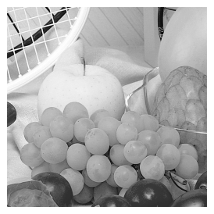

In [14]:
# remove extra boundary from the zero padded image
rows, cols = img_zp.shape # image size
img_crop = img_zp[b:rows-b, b:cols-b] # last index is not included
plot_img_orig(img_crop)

### <span style="color: RoyalBlue; font-weight: bold;">Task 6.3</span> Mean (Average) Filter

This filter (which is also called box filter, because it resembles a box in a 3D view) is the simplest seperable smoothing filter, where all filter coefficients have the same value (typically 1).

Implement the following tasks:
1. Write a function for mean filtering a given image corresponding to a $n\times n$ mask ($n$ should be odd) using zero padding.
2. Test the function using the images *p-building-small.png* and *testpattern-512.png* for $n = 3, 9, 21$. Plot and analyze the results.

*Note*: The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga8c45db9afe636703801b0b2e440fce37">`blur` ↗</a>.

In [15]:
# mean filter given image corresponding to n x n mask (n must be odd)
def mean_filter(img, n):
    # compute offset / padding size
    b = int(n / 2)
    
    # zero padded image
    img_pad = cv2.copyMakeBorder(img, b, b, b, b, cv2.BORDER_CONSTANT)
    
    # size of padded image
    rows, cols = img_pad.shape
    
    # result image
    res = np.zeros(shape=[rows, cols], dtype=np.uint32) # note the data type (0 to 4294967295)
    
    # mean filtering
    for iy in range(b, rows-b):
        for jx in range(b, cols-b):
            # get local neighborhood
            nbh = img_pad[iy-b:iy+b+1, jx-b:jx+b+1]
            
            # compute sum and assign it to the current pixel
            res[iy, jx] = np.sum(nbh)
            
    # normalization (at the end because it is computationally expensive if we did it inside the loop)
    res = res / (n*n)
    
    # remove extra border
    res = res[b:rows-b, b:cols-b]
    
    # return final result
    return res

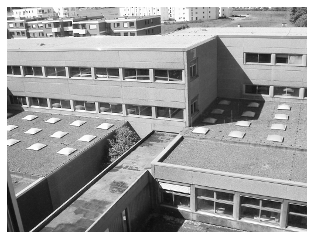

In [16]:
# read image as a grayscale image (parameter 0)
img = cv2.imread('images/p-building-small.png', 0)
plot_img_orig(img)

3x3


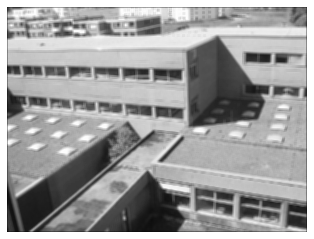

In [17]:
# mean filter image
res_3_3 = mean_filter(img, 3); 
print("3x3"); 
plot_img_orig(res_3_3)

9x9


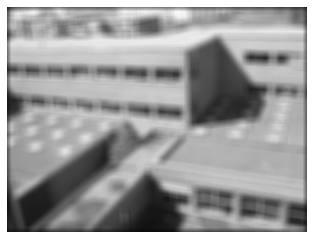

In [18]:
res_9_9 = mean_filter(img, 9); 
print("9x9"); 
plot_img_orig(res_9_9)

21x21


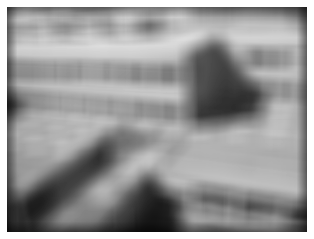

In [19]:
res_21_21 = mean_filter(img, 21); 
print("21x21"); 
plot_img_orig(res_21_21)

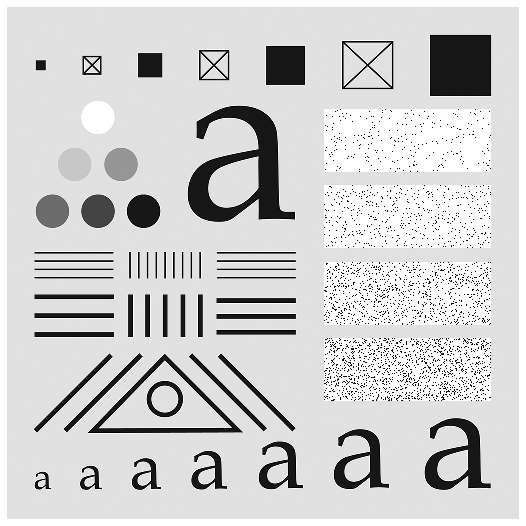

In [20]:
# read image as a grayscale image (parameter 0)
img = cv2.imread('images/testpattern-512.png', 0)
plot_img_orig(img)

3x3


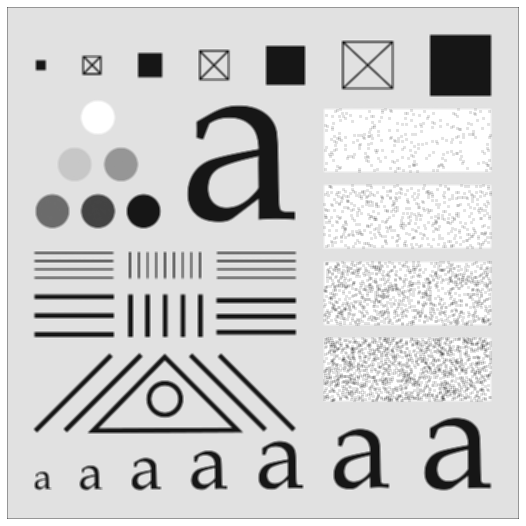

In [21]:
# mean filter image
res_3_3 = mean_filter(img, 3); 
print("3x3")
plot_img_orig(res_3_3)

9x9


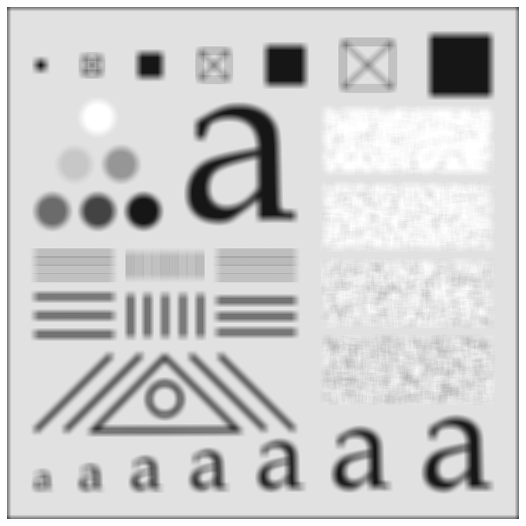

In [22]:
res_9_9 = mean_filter(img, 9); 
print("9x9"); 
plot_img_orig(res_9_9)

21x21


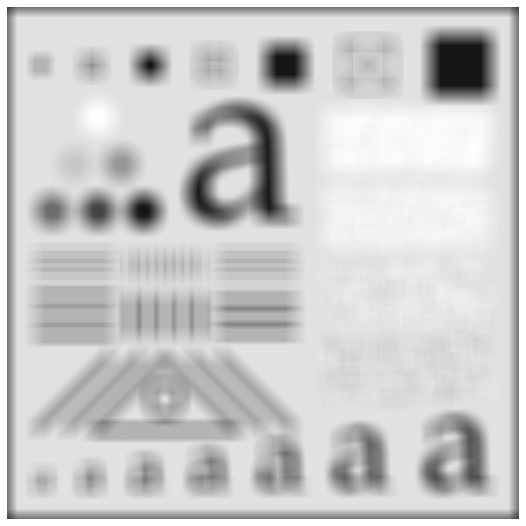

In [23]:
res_21_21 = mean_filter(img, 21); 
print("21x21"); 
plot_img_orig(res_21_21)

As one would expect, the amount of blurring increases with the size of the mask ($n$). As a result, image details are removed. Furthermore, noise becomes smoother and even disappears for large $n$. Image features with a similar size as the filter are affected more than other (larger) structures. Furthermore, the border becomes black due to the influence of the zero padding and also increases with the size of the mask. This effect can be avoided by using another padding method.

### <span style="color: RoyalBlue; font-weight: bold;">Task 6.4</span> Arbitrary Filter Masks

To be flexible, it should be possible to use arbitrary filter masks. The masks can then be specified by a Numpy <a href="https://numpy.org/doc/stable/reference/generated/numpy.array.html">`array` ↗</a>.

Implement the following tasks:
1. Write a function to filter an image by a given $m\times n$ mask (for odd $m, n$ and zero padding). You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.multiply.html">`multiply` ↗</a> from Numpy for element-wise matrix multiplication.
2. Create a Numpy <a href="https://numpy.org/doc/stable/reference/generated/numpy.array.html">`array` ↗</a> corresponding to a $9\times 9$ averaging mask and compare the filtering result with the previous task for the image *testpattern-512.png*.
3. Measure the computation time of the filtering process (you can use the function <a href="https://docs.python.org/3/library/time.html#time.time">`time.time()` ↗</a> for this).

*Note*: The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04">`filter2D` ↗</a>.

In [40]:
# filter given image with given m x n mask
def filter_image(img, mask):
    # compute offset / padding size
    m, n = mask.shape # size of the mask (m x n = rows x cols)
    
    if (m % 2 == 0) or (n % 2 == 0):
        print("Mask must have odd size (returning original image)")
        return img # return unfiltered image

    bh = int(m / 2) # border height (rows)
    bw = int(n / 2) # border width (cols)

    # zero padding
    img_pad = cv2.copyMakeBorder(img, bh, bh, bw, bw, cv2.BORDER_CONSTANT) # top, bottom, left, right
    
    # size of padded image
    rows, cols = img_pad.shape
    
    # result image
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # note the data type (0 to 4294967295)
    
    # filtering
    for iy in range(bh, rows-bh):
        for jx in range(bw, cols-bw):
            # get local neighborhood
            nbh = img_pad[iy-bh:iy+bh+1, jx-bw:jx+bw+1]
            
            # multiply and sum up
            tmp = np.multiply(mask, nbh)
            tmp = np.sum(tmp)
            
            # compute sum and assign it to the current pixel
            res[iy, jx] = tmp
            
    # normalization (at the end because it is computationally expensive)
    res = res / (m*n)
    
    # remove extra border
    res = res[bh:rows-bh, bw:cols-bw]
    
    # return final result
    return res

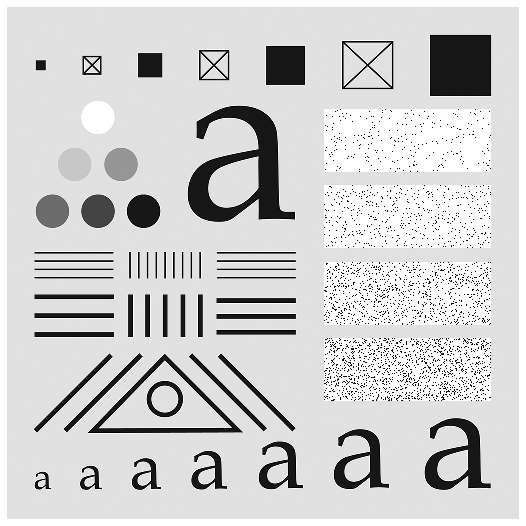

In [41]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/testpattern-512.png', 0)
plot_img_orig(img)

Time for normal filtering: 2.3382985591888428 seconds


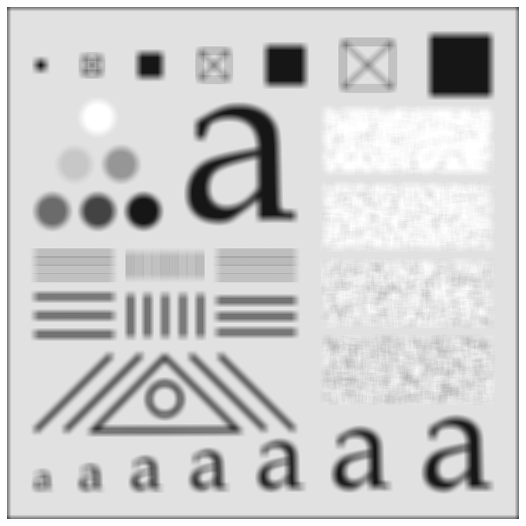

In [42]:
# specify box filter mask
mask = np.ones((9, 9))

# mean filter image
t1 = time.time() ##Starting time flag 
res = filter_image(img, mask)
t2 = time.time() ## Ending time flag
#print(t1, t2)
print("Time for normal filtering: " + str(t2-t1) + " seconds")
plot_img_orig(res)

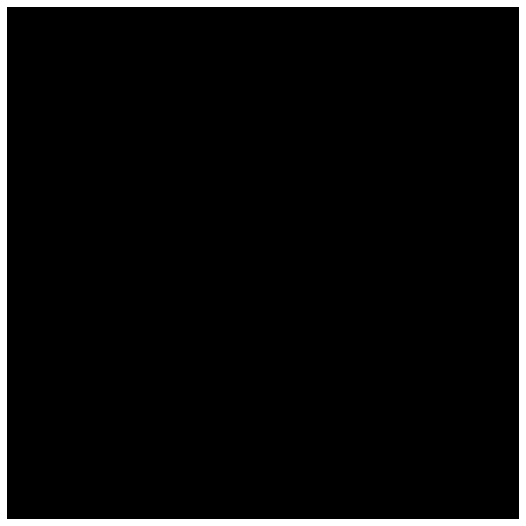

0.0

In [43]:
# check difference to previous task
res_diff = res-res_9_9
plot_img_orig(res_diff)
sum(sum(res_diff))

As the difference image shows, the filtering results are completely identical.

### <span style="color: RoyalBlue; font-weight: bold;">Task 6.5</span> Separable Filters

Implement / solve the following tasks:
1. Seperate the box filter from the previous task into two filters and again compare the filtering result.
2. Again measure the computation time of the filtering process (you can use the function <a href="https://docs.python.org/3/library/time.html#time.time">`time.time()` ↗</a> for this).
3. Analyze the number of operations required for filtering an $M \times N$ image using a $m\times n$ mask and for the case that the corresponding seperated filters are used. Compare the computation times for both cases. Do the seperate filters accelerate the filtering?

Time for seperated filtering: 4.436877012252808 seconds


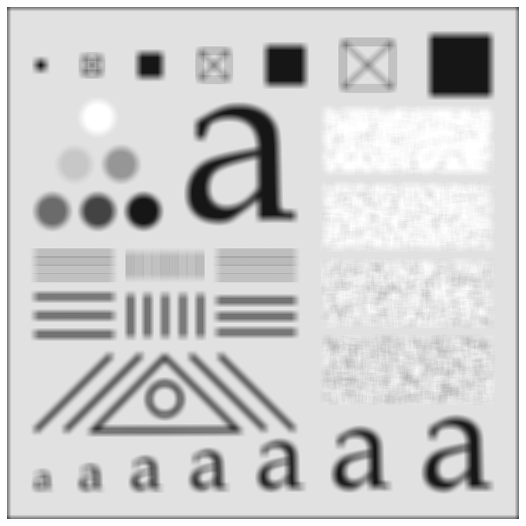

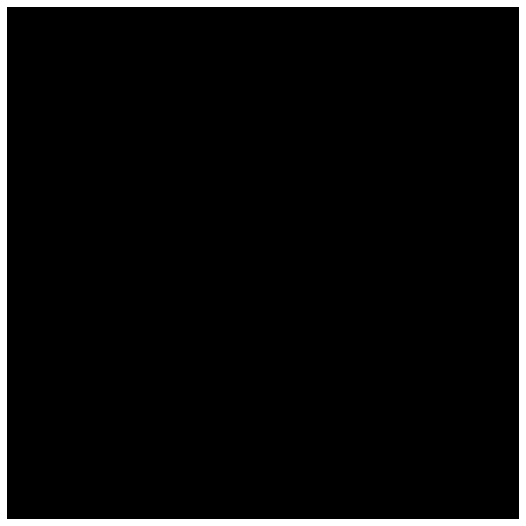

In [28]:
# seperate the box filter
mask1 = np.ones((1, 9))
mask2 = np.ones((9, 1))

t1 = time.time()
res_m1 = filter_image(img, mask1)
res_m2 = filter_image(res_m1, mask2)
t2 = time.time()

print("Time for seperated filtering: " + str(t2-t1) + " seconds")
plot_img_orig(res_m2)

# check difference to previous task
res_diff = res_m2 - res_9_9
plot_img_orig(res_diff)

As the difference image shows, the filtering results are completely identical.

The number of operations can be computed as follows: For an $M \times N$ image and a $m\times n$ mask, we need to process $MN$ pixels. For each pixel, every gray value under the mask is multiplied by the corresponding mask coefficient, and the products are summed up. Therefore, we have $mn$ multiplications and approximately $mn$ additions per pixel. Therefore, we have an order of $MNmn$ operations.

For a seperated filter, we have $m$ multiplications and additions in the first filtering step, and $n$ multiplications and additions in the second step. Therefore, we have $MNm + MNn = MN(m+n)$ filtering steps. The computational advantage (acceleration of the filtering) is therefore:

$$C = \dfrac{MNmn}{MN(m+n)} = \dfrac{mn}{m+n}$$

For large values of $m$ and $n$, this can make a huge difference (e.g. approx. $C = 50$ for $m=n=101$). In this implementation, the seperated filtering is slower than the normal filtering if we use small values for $m$ and $n$. This is because the Numpy slicing and pixel access are computationally expensive and overlay the acceleration. At least a slight acceleration can be found for $m=n=100$. Instead of slicing, we can directly access the pixels. Furthermore, the Numpy function <a href="https://numpy.org/doc/stable/reference/generated/numpy.ndarray.item.html">`item` ↗</a> can be used to work with Python scalars instead of Numpy objects.

*Note*: The divisions for the normalization after the filtering are not taken into account, because these constants are small ($MN$ divisions for normal filtering) compared to the number of the other operations. As a result, they are neglectable for the computational complexity.